In this notebook, we implement **cascased multi-class classification using supervised approach**. The model is trained using the synthetic dataset. The pre-trained model used here is RoBERTa, but it can also be replaced with DeBERTa or other pre-trained models by updating the variable `MODEL_NAME` below.

# Setting Seeds

Here, we begin by setting the random seeds to ensure reproducibility across different runs.

In [1]:
import random
from transformers import set_seed
import os

import pandas as pd
import numpy as np
import warnings
import ast
from transformers import AutoTokenizer, AutoModelForSequenceClassification
from sklearn.metrics import accuracy_score, f1_score, precision_recall_fscore_support, multilabel_confusion_matrix
from sklearn.utils.class_weight import compute_class_weight
import torch
import torch.nn as nn
from transformers import TrainingArguments, Trainer, EarlyStoppingCallback
from datasets import Dataset

import warnings
warnings.filterwarnings('ignore') 

def set_all_seeds(seed=42):
    """Set seeds for reproducible results"""
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)
    set_seed(seed)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False
    os.environ['PYTHONHASHSEED'] = str(seed)

# Set all seeds
set_all_seeds(42)

/opt/anaconda3/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


# Set device

We also set the device to use the GPU if available, for more efficient execution.

In [2]:
if torch.backends.mps.is_available(): 
    device = torch.device("mps")
    print("Using MPS (Apple Silicon GPU)")
elif torch.cuda.is_available():
    device = torch.device("cuda")
    print("Using CUDA")
else:
    device = torch.device("cpu")
    print("Using CPU")

Using MPS (Apple Silicon GPU)


# Load Data and Data Preparation

After setting up the environment configuration, we import the data into the notebook and perform data preparation. Here, we use the **synthetic data** to train the model. The details of each imported dataset are as follows:
1. `survey_df`: Training data generated using ClaudeAI.
4. `survey_test_df`: Testing data generated using ClaudeAI (separate from training and generated with slight prompt modifications).

These datasets can be replaced with other files, as long as they maintain the same characteristics, column names, and data format.

For the data preparation, we perform the following tasks to clean the dataset:
1. Lowercasing and remove non-alphanumeric characters.
2. Remove noisy responses (fewer than 10 characters).
2. Sort and encode the labels.
3. Split training dataset into training and validation sets.

In [2]:
import pandas as pd
from sklearn.preprocessing import MultiLabelBinarizer
from iterstrat.ml_stratifiers import MultilabelStratifiedShuffleSplit
from collections import Counter
import nlpaug.augmenter.word as naw
from collections import defaultdict
import random
import re

### 1. Import clean survey data
survey_df = pd.read_excel('synthetic_data_mixed_labels.xlsx')
survey_test_df = pd.read_excel('synthetic_data_test.xlsx')


### 2. Data Preparation
# a. Student response preprocessing
def text_preprocessing(text):
    # Remove regex (any non-alphanumeric characters) and keeping only letters, numbers, and spaces using regex
    text = re.sub(r'[^a-zA-Z0-9 ]', '', text)

    # Lowercasing
    text = text.lower()

    return text

survey_df['student_response'] = survey_df['student_response'].apply(lambda x: text_preprocessing(x))
survey_test_df['student_response'] = survey_test_df['student_response'].apply(lambda x: text_preprocessing(x))

# b. Remove noisy text
filtered_df = survey_df[survey_df['student_response'].str.len()>10].copy()

# c. Sort and clean the label
filtered_df['all_labels'] = filtered_df['all_labels'].apply(lambda x: sorted(x) if isinstance(x, list) else x)
survey_test_df['all_labels'] = survey_test_df['all_labels'].apply(lambda x: sorted(x) if isinstance(x, list) else x)

def clean_and_sort_labels(x):
    # Convert string labels to list
    if isinstance(x, str):
        x = x.strip()
        if x.startswith("[") and x.endswith("]"):
            try:
                x_list = ast.literal_eval(x)
            except:
                x_list = x.strip("[]").split(",")
        else:
            x_list = x.split(",")
    elif isinstance(x, list):
        x_list = x
    else:
        return []

    # Clean, deduplicate, and sort
    cleaned = {str(item).strip().strip("[]\"'") for item in x_list if str(item).strip().strip("[]\"'")}
    return sorted(cleaned, key=str.lower)

filtered_df['all_labels'] = filtered_df['all_labels'].apply(clean_and_sort_labels)
survey_test_df['all_labels'] = survey_test_df['all_labels'].apply(clean_and_sort_labels)



### 3. Encode the labels
# Encode category label
category_map = {"teaching & delivery": 0, "assignment & quiz": 1, "course materials & structure": 2, "mixed": 3}
filtered_df['category_mixed'] = filtered_df['category_mixed'].map(category_map)
survey_test_df['category_mixed'] = survey_test_df['category_mixed'].map(category_map)

# Encode appropriateness label
app_map = {"inappropriate": 0, "appropriate": 1}
filtered_df['inappropriate_appropriate'] = filtered_df['inappropriate_appropriate'].map(app_map)
survey_test_df['inappropriate_appropriate'] = survey_test_df['inappropriate_appropriate'].map(app_map)


### 4. Split The Data
from sklearn.model_selection import train_test_split

# Split 1: Split out test set
X_test = survey_test_df['student_response'].copy()
y_binary_test = survey_test_df['inappropriate_appropriate'].copy()
y_category_test = survey_test_df['category_mixed'].copy()

# Split 2: Get train_val portion
X_train_val = filtered_df['student_response'].copy()
y_binary_train_val = filtered_df['inappropriate_appropriate'].copy()
y_category_train_val = filtered_df['category_mixed'].copy()

# Create a combined stratification key for both labels
# This ensures both labels are stratified together
stratify_key = y_binary_train_val.astype(str) + '_' + y_category_train_val.astype(str)

# Split train_val into train and validation (8% validation)
X_train, X_val, y_binary_train, y_binary_val, y_category_train, y_category_val = train_test_split(
    X_train_val, y_binary_train_val, y_category_train_val,
    test_size=0.08, random_state=42, stratify=stratify_key
)

# Create DataFrames
train_df = pd.DataFrame({
    "student_response": X_train.values, 
    "inappropriate_appropriate": y_binary_train.values,
    "category": y_category_train.values
})

val_df = pd.DataFrame({
    "student_response": X_val.values, 
    "inappropriate_appropriate": y_binary_val.values,
    "category": y_category_val.values
})

test_df = pd.DataFrame({
    "student_response": X_test.values, 
    "inappropriate_appropriate": y_binary_test.values,
    "category": y_category_test.values
})

### 5. Check the processing result
# Train label distributions
print("Train set shape:", train_df.shape)
print(f'Train proportion binary label: {Counter(y_binary_train)}')
print(f'Train proportion category label: {Counter(y_category_train)}')
print(f'Train combined label distribution:\n{pd.Series(y_binary_train.astype(str) + "_" + y_category_train.astype(str)).value_counts()}\n')

# Validation label distributions
print("Validation set shape:", val_df.shape)
print(f'Validation proportion binary label: {Counter(y_binary_val)}')
print(f'Validation proportion category label: {Counter(y_category_val)}')
print(f'Validation combined label distribution:\n{pd.Series(y_binary_val.astype(str) + "_" + y_category_val.astype(str)).value_counts()}\n')

# Test label distributions
print("Test set shape:", test_df.shape)
print(f'Test proportion binary label: {Counter(y_binary_test)}')
print(f'Test proportion category label: {Counter(y_category_test)}')
print(f'Test combined label distribution:\n{pd.Series(y_binary_test.astype(str) + "_" + y_category_test.astype(str)).value_counts()}\n')

Train set shape: (621, 3)
Train proportion binary label: Counter({1: 466, 0: 155})
Train proportion category label: Counter({3: 210, 0: 154, 2: 148, 1: 109})
Train combined label distribution:
1_3    186
1_2    132
0_0    103
1_1     97
1_0     51
0_3     24
0_2     16
0_1     12
Name: count, dtype: int64

Validation set shape: (54, 3)
Validation proportion binary label: Counter({1: 40, 0: 14})
Validation proportion category label: Counter({3: 18, 2: 13, 0: 13, 1: 10})
Validation combined label distribution:
1_3    16
1_2    11
1_1     9
0_0     9
1_0     4
0_3     2
0_2     2
0_1     1
Name: count, dtype: int64

Test set shape: (104, 3)
Test proportion binary label: Counter({1: 73, 0: 31})
Test proportion category label: Counter({3: 44, 0: 23, 1: 19, 2: 18})
Test combined label distribution:
1_3    30
1_1    17
1_2    14
0_3    14
1_0    12
0_0    11
0_2     4
0_1     2
Name: count, dtype: int64



# Model Setup

Here, we define the model architecture to perform supervised training for two classification tasks: appropriateness and categorization. The appropriateness and categorization tasks here will be performed as **single-label classification** for each response. 

As mentioned earlier, we are currently using RoBERTa in this notebook, but it can be changed by updating the `MODEL_NAME` variable below.

In [4]:
from datasets import Sequence, Value
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score
from transformers import AutoTokenizer, AutoModelForSequenceClassification, AutoModel
import torch.nn as nn
from tqdm import tqdm
from torch.utils.data import DataLoader

### 1. Load models
MODEL_NAME = "roberta-base"

### 2. Load tokenizer
tokenizer = AutoTokenizer.from_pretrained(MODEL_NAME, use_fast=False)

### 3. Define Model Architecture
# Classifier 1: Binary classification for appropriateness prediction
appropriate_model = AutoModelForSequenceClassification.from_pretrained(
    MODEL_NAME, 
    num_labels=2,
    problem_type="single_label_classification"
).to(device)

# Classifier 2: Multi-class classification for categories
class CascadedCategoryModel(nn.Module):
    def __init__(self, base_model_name, num_category_classes=3):
        super().__init__()
        self.roberta = AutoModel.from_pretrained(base_model_name)
        hidden_size = self.roberta.config.hidden_size
        
        # Category classifier head
        self.classifier = nn.Sequential(
            nn.Dropout(0.3),
            nn.Linear(hidden_size, hidden_size // 2),
            nn.ReLU(),
            nn.Dropout(0.3),
            nn.Linear(hidden_size // 2, num_category_classes)
        )
        
    def forward(self, input_ids, attention_mask):
        outputs = self.roberta(input_ids=input_ids, attention_mask=attention_mask)
        pooled_output = outputs.last_hidden_state[:, 0, :]  # Use CLS token
        logits = self.classifier(pooled_output)
        return type('ModelOutput', (), {'logits': logits})()

category_model = CascadedCategoryModel(MODEL_NAME).to(device)

### 4. Freeze transformer layers
def freeze_lower_layers(model, num_layers_to_freeze=8):
        
    for param in model.roberta.embeddings.parameters():
        param.requires_grad = False
    
    total_layers = len(model.roberta.encoder.layer)
    layers_to_freeze = min(num_layers_to_freeze, total_layers)
    
    for i in range(layers_to_freeze):
        for param in model.roberta.encoder.layer[i].parameters():
            param.requires_grad = False
    
    print(f"Frozen first {layers_to_freeze} layers and embeddings")

    total_params = sum(p.numel() for p in model.parameters())
    trainable_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
    print(f"Total parameters: {total_params:,}")
    print(f"Trainable parameters: {trainable_params:,}")
    print(f"Frozen parameters: {total_params - trainable_params:,}")

# Apply freezing
freeze_lower_layers(appropriate_model, num_layers_to_freeze=10)
freeze_lower_layers(category_model, num_layers_to_freeze=8)

### 5. Prepare datasets
def prepare_datasets(train_df, val_df, test_df):
    train_dataset = Dataset.from_pandas(train_df)
    val_dataset = Dataset.from_pandas(val_df)
    test_dataset = Dataset.from_pandas(test_df)

    def tokenize(batch):
        texts = [str(x) for x in batch["student_response"]] 
        return tokenizer(texts, 
                         padding="max_length", 
                         truncation=True, 
                         max_length=256)

    train_dataset = train_dataset.map(tokenize, batched=True)
    val_dataset = val_dataset.map(tokenize, batched=True)
    test_dataset = test_dataset.map(tokenize, batched=True)

    # Define columns to keep
    keep_cols = ["input_ids", "attention_mask", "inappropriate_appropriate", "category", "student_response"]

    train_dataset = train_dataset.remove_columns([c for c in train_dataset.column_names if c not in keep_cols])
    val_dataset = val_dataset.remove_columns([c for c in val_dataset.column_names if c not in keep_cols])
    test_dataset = test_dataset.remove_columns([c for c in test_dataset.column_names if c not in keep_cols])

    # Cast labels to proper types
    train_dataset = train_dataset.cast_column("inappropriate_appropriate", Value("int64"))
    val_dataset = val_dataset.cast_column("inappropriate_appropriate", Value("int64"))
    test_dataset = test_dataset.cast_column("inappropriate_appropriate", Value("int64"))
    
    train_dataset = train_dataset.cast_column("category", Value("int64"))
    val_dataset = val_dataset.cast_column("category", Value("int64"))
    test_dataset = test_dataset.cast_column("category", Value("int64"))

    # Set format for PyTorch
    train_dataset.set_format("torch", columns=["input_ids", "attention_mask", "inappropriate_appropriate", "category"])
    val_dataset.set_format("torch", columns=["input_ids", "attention_mask", "inappropriate_appropriate", "category"])
    test_dataset.set_format("torch", columns=["input_ids", "attention_mask", "inappropriate_appropriate", "category"])
    
    return train_dataset, val_dataset, test_dataset

train_dataset, val_dataset, test_dataset = prepare_datasets(train_df, val_df, test_df)

### 6. Evaluation metrics
def compute_metrics_binary(predictions, labels):
    # Metrics for binary classification
    predictions = torch.argmax(predictions, dim=1).cpu().numpy()
    labels = labels.cpu().numpy()
    
    accuracy = accuracy_score(labels, predictions)
    precision = precision_score(labels, predictions, average='binary', zero_division=0)
    recall = recall_score(labels, predictions, average='binary', zero_division=0)
    f1 = f1_score(labels, predictions, average='binary', zero_division=0)
    
    return {
        "accuracy": accuracy,
        "precision": precision,
        "recall": recall,
        "f1": f1
    }

def compute_metrics_multiclass(predictions, labels):
    # Metrics for multi-class classification
    predictions = torch.argmax(predictions, dim=1).cpu().numpy()
    labels = labels.cpu().numpy()
    
    accuracy = accuracy_score(labels, predictions)
    f1_macro = f1_score(labels, predictions, average='macro', zero_division=0)
    f1_weighted = f1_score(labels, predictions, average='weighted', zero_division=0)
    
    return {
        "accuracy": accuracy,
        "f1_macro": f1_macro,
        "f1_weighted": f1_weighted
    }

### 7. Calculate class weights
def calculate_class_weights(labels_array, num_classes):
    """Calculate class weights for imbalanced datasets"""
    unique_labels, counts = np.unique(labels_array, return_counts=True)
    total_samples = len(labels_array)
    
    class_weights = torch.ones(num_classes, dtype=torch.float32)
    for label, count in zip(unique_labels, counts):
        if label < num_classes:  # Safety check
            class_weights[label] = total_samples / (num_classes * count)
    
    return class_weights.to(device)

# Calculate weights for both stages
app_weights = calculate_class_weights(train_df['inappropriate_appropriate'].values, 2)
cat_weights = calculate_class_weights(train_df['category'].values, 3)

print(f"Appropriate/Inappropriate class weights: {app_weights}")
print(f"Category class weights: {cat_weights}")

Some weights of RobertaForSequenceClassification were not initialized from the model checkpoint at roberta-base and are newly initialized: ['classifier.dense.bias', 'classifier.dense.weight', 'classifier.out_proj.bias', 'classifier.out_proj.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.
Some weights of RobertaModel were not initialized from the model checkpoint at roberta-base and are newly initialized: ['pooler.dense.bias', 'pooler.dense.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


Frozen first 10 layers and embeddings
Total parameters: 124,647,170
Trainable parameters: 14,767,874
Frozen parameters: 109,879,296
Frozen first 8 layers and embeddings
Total parameters: 124,942,083
Trainable parameters: 29,238,531
Frozen parameters: 95,703,552


Casting the dataset: 100%|██████████| 104/104 [00:00<00:00, 53999.46 examples/s]


Appropriate/Inappropriate class weights: tensor([1.9904, 0.6677], device='mps:0')
Category class weights: tensor([1.3442, 1.8991, 1.3529], device='mps:0')


# Training Loop

Below is the training function used to begin the model training loop.

In [5]:
import torch
import torch.nn as nn
from torch.utils.data import DataLoader
from sklearn.metrics import f1_score
import numpy as np
from tqdm import tqdm
import os
import pandas as pd

print(f"Using device: {device}") 

def train_cascaded_roberta(appropriate_model, category_model,
                           train_dataset, val_dataset,
                           app_weights, cat_weights,
                           epochs_stage1=5, epochs_stage2=10, 
                           lr_stage1=2e-5, lr_stage2=1e-5,
                           batch_size=16,
                           device=None, patience=5, 
                           freeze_roberta=False,
                           results_dir="./results_cascaded_multi_class"):
    
    # Create results directory
    os.makedirs(results_dir, exist_ok=True)
    
    # Create data loaders
    train_dataloader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)
    val_dataloader = DataLoader(val_dataset, batch_size=batch_size, shuffle=False)

    # Stage 1 setup
    optimizer = torch.optim.AdamW(appropriate_model.parameters(), lr=lr_stage1, weight_decay=0.01)
    scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
        optimizer, mode='min', factor=0.5, patience=2, verbose=True
    )
    loss_fn = nn.CrossEntropyLoss(weight=app_weights)
    
    best_val_loss = float('inf')
    patience_counter = 0
    all_stage1_metrics = []
    
    # Stage 1 training loop
    print("Classifier 1: Appropriateness Prediction")

    for epoch in range(epochs_stage1):
        # Training phase
        appropriate_model.train()
        total_loss = 0
        progress_bar = tqdm(train_dataloader, desc=f"Stage 1 Epoch {epoch + 1}")
        
        for batch in progress_bar:
            input_ids = batch['input_ids'].to(device)
            attention_mask = batch['attention_mask'].to(device)
            labels = batch['inappropriate_appropriate'].to(device)
            
            optimizer.zero_grad()
            
            outputs = appropriate_model(input_ids=input_ids, attention_mask=attention_mask)
            loss = loss_fn(outputs.logits, labels)
            
            loss.backward()
            torch.nn.utils.clip_grad_norm_(appropriate_model.parameters(), max_norm=1.0)
            optimizer.step()
            
            total_loss += loss.item()
            progress_bar.set_postfix({'loss': loss.item()})
        
        # Validation phase
        appropriate_model.eval()
        val_loss = 0
        all_predictions = []
        all_labels = []
        
        with torch.no_grad():
            for batch in val_dataloader:
                input_ids = batch['input_ids'].to(device)
                attention_mask = batch['attention_mask'].to(device)
                labels = batch['inappropriate_appropriate'].to(device)
                
                outputs = appropriate_model(input_ids=input_ids, attention_mask=attention_mask)
                loss = loss_fn(outputs.logits, labels)
                
                val_loss += loss.item()
                all_predictions.append(outputs.logits)
                all_labels.append(labels)
        
        all_predictions = torch.cat(all_predictions, dim=0)
        all_labels = torch.cat(all_labels, dim=0)
        
        metrics = compute_metrics_binary(all_predictions, all_labels)
        avg_train_loss = total_loss / len(train_dataloader)
        avg_val_loss = val_loss / len(val_dataloader)
        
        print(f"Epoch {epoch+1}/{epochs_stage1} | Train Loss: {avg_train_loss:.3f} | Val Loss: {avg_val_loss:.3f} | Accuracy: {metrics['accuracy']:.3f} | F1: {metrics['f1']:.3f} | Precision: {metrics['precision']:.3f} | Recall: {metrics['recall']:.3f}")
        
        # Save metrics
        epoch_metrics = metrics.copy()
        epoch_metrics.update({
            'epoch': epoch + 1,
            'train_loss': avg_train_loss,
            'val_loss': avg_val_loss,
            'stage': 'appropriate_inappropriate'
        })
        all_stage1_metrics.append(epoch_metrics)
        
        # Learning rate scheduling
        scheduler.step(avg_val_loss)
        
        # Early stopping
        if avg_val_loss < best_val_loss:
            best_val_loss = avg_val_loss
            patience_counter = 0
            torch.save(appropriate_model.state_dict(), f"{results_dir}/best_appropriateness_model.pt")
            print("New best model saved.")
        else:
            patience_counter += 1
            print(f"No improvement. Patience: {patience_counter}/{patience}")
            
            if patience_counter >= patience:
                print("Early stopping triggered.")
                break
    
    # Load best stage 1 model
    appropriate_model.load_state_dict(torch.load(f"{results_dir}/best_appropriateness_model.pt"))
    
    ### Get appropriate samples for stage 2 ###

    # Filter training data
    appropriate_model.eval()
    train_dataloader_filter = DataLoader(train_dataset, batch_size=batch_size, shuffle=False)
    
    train_appropriate_indices = []
    current_idx = 0
    
    with torch.no_grad():
        for batch in tqdm(train_dataloader_filter, desc="Filtering training samples"):
            input_ids = batch['input_ids'].to(device)
            attention_mask = batch['attention_mask'].to(device)
            
            outputs = appropriate_model(input_ids=input_ids, attention_mask=attention_mask)
            predictions = torch.argmax(outputs.logits, dim=1)
            
            # Find indices where prediction is 1 (appropriate)
            batch_appropriate = (predictions == 1).nonzero(as_tuple=True)[0]
            global_indices = current_idx + batch_appropriate
            train_appropriate_indices.extend(global_indices.cpu().numpy())
            
            current_idx += len(batch['input_ids'])
    
    # Filter validation data
    val_dataloader_filter = DataLoader(val_dataset, batch_size=batch_size, shuffle=False)
    
    val_appropriate_indices = []
    current_idx = 0
    
    with torch.no_grad():
        for batch in tqdm(val_dataloader_filter, desc="Filtering validation samples"):
            input_ids = batch['input_ids'].to(device)
            attention_mask = batch['attention_mask'].to(device)
            
            outputs = appropriate_model(input_ids=input_ids, attention_mask=attention_mask)
            predictions = torch.argmax(outputs.logits, dim=1)
            
            # Find indices where prediction is 1 (appropriate)
            batch_appropriate = (predictions == 1).nonzero(as_tuple=True)[0]
            global_indices = current_idx + batch_appropriate
            val_appropriate_indices.extend(global_indices.cpu().numpy())
            
            current_idx += len(batch['input_ids'])
    
    print(f"Filtered {len(train_appropriate_indices)} appropriate samples from {len(train_dataset)} total training samples")
    print(f"Training filtering percentage: {len(train_appropriate_indices)/len(train_dataset)*100:.2f}%")
    print(f"Filtered {len(val_appropriate_indices)} appropriate samples from {len(val_dataset)} total validation samples")
    print(f"Validation filtering percentage: {len(val_appropriate_indices)/len(val_dataset)*100:.2f}%")

    
    # Create filtered datasets
    filtered_train_data = train_dataset.select(train_appropriate_indices)
    filtered_val_data = val_dataset.select(val_appropriate_indices)
    
    print(f"Filtered training samples: {len(filtered_train_data)}")
    print(f"Filtered validation samples: {len(filtered_val_data)}")
    
    # Check category distribution
    train_categories = [filtered_train_data[i]['category'].item() for i in range(len(filtered_train_data))]
    unique_labels, counts = np.unique(train_categories, return_counts=True)
    
    print("Category distribution in filtered training data:")
    for label, count in zip(unique_labels, counts):
        print(f"  Category {label}: {count} samples ({count/len(train_categories)*100:.2f}%)")
    
    # Create filtered data loaders
    train_loader_filtered = DataLoader(filtered_train_data, batch_size=batch_size, shuffle=True)
    val_loader_filtered = DataLoader(filtered_val_data, batch_size=batch_size, shuffle=False)
    
    # Stage 2 setup
    print(f"\nClassifier 2: Categorisation Prediction")
    
    if freeze_roberta:
        # Only train the classifier head
        optimizer_stage2 = torch.optim.AdamW(category_model.classifier.parameters(), lr=lr_stage2, weight_decay=0.01)
    else:
        # Train last few layers + classifier head with different learning rates
        optimizer_stage2 = torch.optim.AdamW([
            {'params': [p for p in category_model.roberta.parameters() if p.requires_grad], 'lr': lr_stage2 / 10},
            {'params': category_model.classifier.parameters(), 'lr': lr_stage2}
        ], weight_decay=0.01)
    
    scheduler_stage2 = torch.optim.lr_scheduler.ReduceLROnPlateau(
        optimizer_stage2, mode='min', factor=0.7, patience=4, verbose=True, min_lr=1e-6
    )
    
    cat_weights_filtered = calculate_class_weights(train_categories, num_classes=3)
    loss_fn_stage2 = nn.CrossEntropyLoss(weight=cat_weights_filtered)
    
    best_val_loss_stage2 = float('inf')
    patience_counter_stage2 = 0
    all_stage2_metrics = []
    
    # Stage 2 training loop
    for epoch in range(epochs_stage2):
        # Training phase
        if freeze_roberta:
            category_model.roberta.eval()  # Keep RoBERTa frozen
        else:
            category_model.roberta.train()  # Allow RoBERTa to train
        
        category_model.classifier.train()
        total_loss = 0
        progress_bar = tqdm(train_loader_filtered, desc=f"Stage 2 Epoch {epoch + 1}")
        
        for batch in progress_bar:
            input_ids = batch['input_ids'].to(device)
            attention_mask = batch['attention_mask'].to(device)
            labels = batch['category'].to(device)
            
            optimizer_stage2.zero_grad()
            
            outputs = category_model(input_ids=input_ids, attention_mask=attention_mask)
            loss = loss_fn_stage2(outputs.logits, labels)
            
            loss.backward()
            torch.nn.utils.clip_grad_norm_(category_model.parameters(), max_norm=1.0)
            optimizer_stage2.step()
            
            total_loss += loss.item()
            progress_bar.set_postfix({'loss': loss.item()})
        
        # Validation phase
        category_model.eval()
        val_loss = 0
        all_predictions_stage2 = []
        all_labels_stage2 = []
        
        with torch.no_grad():
            for batch in val_loader_filtered:
                input_ids = batch['input_ids'].to(device)
                attention_mask = batch['attention_mask'].to(device)
                labels = batch['category'].to(device)
                
                outputs = category_model(input_ids=input_ids, attention_mask=attention_mask)
                loss = loss_fn_stage2(outputs.logits, labels)
                
                val_loss += loss.item()
                all_predictions_stage2.append(outputs.logits)
                all_labels_stage2.append(labels)
        
        all_predictions_stage2 = torch.cat(all_predictions_stage2, dim=0)
        all_labels_stage2 = torch.cat(all_labels_stage2, dim=0)
        
        metrics_stage2 = compute_metrics_multiclass(all_predictions_stage2, all_labels_stage2)
        avg_train_loss_stage2 = total_loss / len(train_loader_filtered)
        avg_val_loss_stage2 = val_loss / len(val_loader_filtered)
        
        print(f"Epoch {epoch+1}/{epochs_stage2} | Train Loss: {avg_train_loss_stage2:.3f} | Val Loss: {avg_val_loss_stage2:.3f} | Accuracy: {metrics_stage2['accuracy']:.3f} | F1 Macro: {metrics_stage2['f1_macro']:.3f} | F1 Weighted: {metrics_stage2['f1_weighted']:.3f}")
        
        # Save metrics
        epoch_metrics_stage2 = metrics_stage2.copy()
        epoch_metrics_stage2.update({
            'epoch': epoch + 1,
            'train_loss': avg_train_loss_stage2,
            'val_loss': avg_val_loss_stage2,
            'stage': 'category'
        })
        all_stage2_metrics.append(epoch_metrics_stage2)
        
        # Learning rate scheduling
        scheduler_stage2.step(avg_val_loss_stage2)
        
        # Early stopping
        if avg_val_loss_stage2 < best_val_loss_stage2:
            best_val_loss_stage2 = avg_val_loss_stage2
            patience_counter_stage2 = 0
            torch.save(category_model.state_dict(), f"{results_dir}/best_categorisation_model.pt")
            print("New best model saved.")
        else:
            patience_counter_stage2 += 1
            print(f"No improvement. Patience: {patience_counter_stage2}/{patience}")
            
            if patience_counter_stage2 >= patience:
                print("Early stopping triggered.")
                break
    
    # Load best stage 2 model
    category_model.load_state_dict(torch.load(f"{results_dir}/best_categorisation_model.pt"))
    
    # Combine and save training history
    stage1_df = pd.DataFrame(all_stage1_metrics)
    stage2_df = pd.DataFrame(all_stage2_metrics)
    combined_history = pd.concat([stage1_df, stage2_df], ignore_index=True)
    
    # Save training history
    combined_history.to_csv(f"{results_dir}/training_history.csv", index=False)
    
    # Save tokenizer
    tokenizer.save_pretrained(f"{results_dir}/tokenizer")
    
    print(f"\nTraining completed.")
    print(f"Results saved to: {results_dir}")
    
    return appropriate_model, category_model, tokenizer, combined_history

Using device: mps


In [6]:
# Train the cascaded model
appropriate_model, category_model, tokenizer, training_history_df = train_cascaded_roberta(
    appropriate_model=appropriate_model,
    category_model=category_model,
    train_dataset=train_dataset,
    val_dataset=val_dataset,
    app_weights=app_weights,
    cat_weights=cat_weights,
    epochs_stage1=5, 
    epochs_stage2=16,
    batch_size=8,
    device=device
)

# Display training history
training_history_df

Classifier 1: Appropriateness Prediction


Stage 1 Epoch 1: 100%|██████████| 78/78 [01:14<00:00,  1.05it/s, loss=0.067] 


Epoch 1/5 | Train Loss: 0.499 | Val Loss: 0.081 | Accuracy: 0.963 | F1: 0.975 | Precision: 1.000 | Recall: 0.951
New best model saved.


Stage 1 Epoch 2: 100%|██████████| 78/78 [01:16<00:00,  1.01it/s, loss=0.000333]


Epoch 2/5 | Train Loss: 0.061 | Val Loss: 0.000 | Accuracy: 1.000 | F1: 1.000 | Precision: 1.000 | Recall: 1.000
New best model saved.


...

Stage 2 Epoch 15: 100%|██████████| 58/58 [01:07<00:00,  1.16s/it, loss=1.14] 


Epoch 15/16 | Train Loss: 1.055 | Val Loss: 1.038 | Accuracy: 0.463 | F1 Macro: 0.331 | F1 Weighted: 0.329
New best model saved.


Stage 2 Epoch 16: 100%|██████████| 58/58 [01:07<00:00,  1.16s/it, loss=1.05] 


Epoch 16/16 | Train Loss: 1.059 | Val Loss: 1.023 | Accuracy: 0.439 | F1 Macro: 0.312 | F1 Weighted: 0.311
New best model saved.

Training completed.
Results saved to: ./results_cascaded_multi_class


,accuracy,precision,recall,f1,epoch,train_loss,val_loss,stage,f1_macro,f1_weighted
0,0.962963,1.0,0.95122,0.975,1,0.499194,0.081397,appropriate_inappropriate,NaN,NaN
1,1.000000,1.0,1.00000,1.000,2,0.061229,0.000450,appropriate_inappropriate,NaN,NaN
2,1.000000,1.0,1.00000,1.000,3,0.018855,0.004396,appropriate_inappropriate,NaN,NaN
3,1.000000,1.0,1.00000,1.000,4,0.017452,0.000031,appropriate_inappropriate,NaN,NaN
4,1.000000,1.0,1.00000,1.000,5,0.007045,0.000034,appropriate_inappropriate,NaN,NaN
5,0.219512,NaN,NaN,NaN,1,1.106122,1.106814,category,0.090000,0.079024
6,0.219512,NaN,NaN,NaN,2,1.105012,1.100664,category,0.090000,0.079024
7,0.219512,NaN,NaN,NaN,3,1.094889,1.097161,category,0.090000,0.079024
8,0.219512,NaN,NaN,NaN,4,1.094106,1.090501,category,0.090000,0.079024
9,0.219512,NaN,NaN,NaN,5,1.100601,1.086486,category,0.090000,0.079024


# Analysis

We use this to quickly analyze the training results and effectively assess the trained model performance.

In [11]:
import matplotlib.pyplot as plt
import numpy as np
import torch
from sklearn.metrics import classification_report, confusion_matrix, multilabel_confusion_matrix
import seaborn as sns
import pandas as pd
import torch.nn as nn
import os
from transformers import AutoTokenizer, AutoModel
from sklearn.metrics import f1_score, accuracy_score, precision_score, recall_score

def plot_cascaded_training_curves(training_history_df):
    # Separate the two stages
    stage1_df = training_history_df[training_history_df['stage'] == 'appropriate_inappropriate'].copy()
    stage2_df = training_history_df[training_history_df['stage'] == 'category'].copy()
    
    fig, axes = plt.subplots(2, 2, figsize=(15, 10))
    fig.suptitle('Cascaded Model Training Progress', fontsize=16, fontweight='bold')

    # Stage 1 - Appropriateness Classification
    if not stage1_df.empty:
        epochs1 = stage1_df['epoch'].values
        train_loss1 = stage1_df['train_loss'].values
        val_loss1 = stage1_df['val_loss'].values

        # Loss curves for Stage 1 (top-left)
        axes[0, 0].plot(epochs1, train_loss1, 'b-', label='Training Loss', linewidth=2)
        axes[0, 0].plot(epochs1, val_loss1, 'r-', label='Validation Loss', linewidth=2)
        axes[0, 0].set_title('Stage 1: Appropriateness Classification - Loss')
        axes[0, 0].set_xlabel('Epoch')
        axes[0, 0].set_ylabel('Loss')
        axes[0, 0].legend()
        axes[0, 0].grid(True, alpha=0.3)

        # Stage 1 metrics (top-right)
        accuracy1 = stage1_df['accuracy'].values
        f1_1 = stage1_df['f1'].values
        precision1 = stage1_df['precision'].values
        recall1 = stage1_df['recall'].values

        axes[0, 1].plot(epochs1, accuracy1, 'g-', label='Accuracy', linewidth=2)
        axes[0, 1].plot(epochs1, f1_1, 'b-', label='F1 Score', linewidth=2)
        axes[0, 1].plot(epochs1, precision1, 'orange', label='Precision', linewidth=2)
        axes[0, 1].plot(epochs1, recall1, 'red', label='Recall', linewidth=2)
        axes[0, 1].set_title('Stage 1: Appropriateness Classification - Metrics')
        axes[0, 1].set_xlabel('Epoch')
        axes[0, 1].set_ylabel('Score')
        axes[0, 1].legend()
        axes[0, 1].set_ylim(0, 1)
        axes[0, 1].grid(True, alpha=0.3)

    # Stage 2 - Category Classification
    if not stage2_df.empty:
        epochs2 = stage2_df['epoch'].values
        train_loss2 = stage2_df['train_loss'].values
        val_loss2 = stage2_df['val_loss'].values

        # Loss curves for Stage 2 (bottom-left)
        axes[1, 0].plot(epochs2, train_loss2, 'b-', label='Training Loss', linewidth=2)
        axes[1, 0].plot(epochs2, val_loss2, 'r-', label='Validation Loss', linewidth=2)
        axes[1, 0].set_title('Stage 2: Category Classification - Loss')
        axes[1, 0].set_xlabel('Epoch')
        axes[1, 0].set_ylabel('Loss')
        axes[1, 0].legend()
        axes[1, 0].grid(True, alpha=0.3)

        # Stage 2 metrics (bottom-right)
        accuracy2 = stage2_df['accuracy'].values
        f1_macro2 = stage2_df['f1_macro'].values
        f1_weighted2 = stage2_df['f1_weighted'].values

        axes[1, 1].plot(epochs2, accuracy2, 'g-', label='Accuracy', linewidth=2)
        axes[1, 1].plot(epochs2, f1_macro2, 'b-', label='F1 Macro', linewidth=2)
        axes[1, 1].plot(epochs2, f1_weighted2, 'orange', label='F1 Weighted', linewidth=2)
        axes[1, 1].set_title('Stage 2: Category Classification - Metrics')
        axes[1, 1].set_xlabel('Epoch')
        axes[1, 1].set_ylabel('Score')
        axes[1, 1].legend()
        axes[1, 1].set_ylim(0, 1)
        axes[1, 1].grid(True, alpha=0.3)

    plt.tight_layout()
    plt.show()

def get_cascaded_predictions(appropriate_model, category_model, test_dataloader, device):

    appropriate_model.eval()
    category_model.eval()

    all_app_logits, all_app_labels = [], []
    all_cat_logits, all_cat_labels = [], []
    all_app_probs = []

    with torch.no_grad():
        for batch in test_dataloader:
            input_ids = batch['input_ids'].to(device)
            attention_mask = batch['attention_mask'].to(device)
            app_labels = batch['inappropriate_appropriate'].to(device)
            cat_labels = batch['category'].to(device)

            # Appropriateness forward pass
            app_outputs = appropriate_model(input_ids=input_ids, attention_mask=attention_mask)
            app_logits = app_outputs.logits
            app_probs = torch.softmax(app_logits, dim=1)

            # Category forward pass (for all samples, filtering happens in evaluation)
            cat_outputs = category_model(input_ids=input_ids, attention_mask=attention_mask)
            cat_logits = cat_outputs.logits

            # Collect outputs
            all_app_logits.append(app_logits.cpu())
            all_app_labels.append(app_labels.cpu())
            all_cat_logits.append(cat_logits.cpu())
            all_cat_labels.append(cat_labels.cpu())
            all_app_probs.append(app_probs.cpu())

    # Stack results
    app_logits = torch.cat(all_app_logits, dim=0).numpy()
    app_true = torch.cat(all_app_labels, dim=0).numpy()
    cat_logits = torch.cat(all_cat_logits, dim=0).numpy()
    cat_true = torch.cat(all_cat_labels, dim=0).numpy()
    app_probs = torch.cat(all_app_probs, dim=0).numpy()

    app_pred = np.argmax(app_logits, axis=1)
    cat_pred = np.argmax(cat_logits, axis=1)

    return app_pred, app_true, app_logits, cat_pred, cat_true, cat_logits, app_probs

def plot_cascaded_confusion_matrices(app_true, app_pred, cat_true, cat_pred, class_names):
    
    fig, axes = plt.subplots(1, 2, figsize=(12, 5))
    
    # Appropriateness confusion matrix
    cm_app = confusion_matrix(app_true, app_pred)
    sns.heatmap(cm_app, annot=True, fmt='d', cmap='Blues', ax=axes[0],
               xticklabels=['Inappropriate', 'Appropriate'],
               yticklabels=['Inappropriate', 'Appropriate'])
    axes[0].set_title('Stage 1: Appropriateness Classification')
    axes[0].set_xlabel('Predicted')
    axes[0].set_ylabel('Actual')
    
    # Category confusion matrix (only for samples predicted as appropriate)
    app_pred_mask = (app_pred == 1)  # Samples predicted as appropriate
    app_true_mask = (app_true == 1)   # Samples that are actually appropriate
    
    if app_pred_mask.sum() > 0:
        cat_true_filtered = cat_true[app_pred_mask]
        cat_pred_filtered = cat_pred[app_pred_mask]
        
        cm_cat = confusion_matrix(cat_true_filtered, cat_pred_filtered, 
                                 labels=list(range(len(class_names))))
        sns.heatmap(cm_cat, annot=True, fmt='d', cmap='Oranges', ax=axes[1],
                   xticklabels=class_names,
                   yticklabels=class_names)
        axes[1].set_title(f'Stage 2: Category Classification\n(Samples Predicted as Appropriate, n={app_pred_mask.sum()})')
    else:
        axes[1].text(0.5, 0.5, 'No samples predicted\nas appropriate', 
                    ha='center', va='center', transform=axes[1].transAxes)
        axes[1].set_title('Stage 2: Category Classification')
    
    axes[1].set_xlabel('Predicted')
    axes[1].set_ylabel('Actual')
    
    plt.suptitle('Cascaded Model Confusion Matrices', fontsize=16, fontweight='bold')
    plt.tight_layout()
    plt.show()

def plot_cascaded_confidence_distributions(app_logits, app_true, cat_logits, cat_true, app_pred, class_names):
    
    fig, axes = plt.subplots(1, 2, figsize=(12, 4))
    
    # Appropriateness confidence distribution
    app_probs = torch.softmax(torch.tensor(app_logits), dim=1).numpy()[:, 1]  # Probability of appropriate
    
    appropriate_probs = app_probs[app_true == 1]
    inappropriate_probs = app_probs[app_true == 0]
    
    axes[0].hist(inappropriate_probs, bins=20, alpha=0.7, color='red',
                label='Inappropriate (True)', edgecolor='black')
    axes[0].hist(appropriate_probs, bins=20, alpha=0.7, color='green',
                label='Appropriate (True)', edgecolor='black')
    axes[0].axvline(x=0.5, color='black', linestyle='--', label='Threshold')
    axes[0].set_title('Stage 1: Appropriateness Confidence Distribution')
    axes[0].set_xlabel('Confidence Score (Appropriate)')
    axes[0].set_ylabel('Frequency')
    axes[0].legend()
    axes[0].grid(True, alpha=0.3)
    
    # Category confidence distribution (only for samples predicted as appropriate)
    app_pred_mask = (app_pred == 1)
    if app_pred_mask.sum() > 0:
        cat_probs = torch.softmax(torch.tensor(cat_logits[app_pred_mask]), dim=1).numpy()
        cat_true_filtered = cat_true[app_pred_mask]
        cat_pred_filtered = np.argmax(cat_probs, axis=1)
        
        # Plot max confidence for each sample
        max_confidence = np.max(cat_probs, axis=1)
        
        correct_mask = (cat_pred_filtered == cat_true_filtered)
        correct_conf = max_confidence[correct_mask]
        incorrect_conf = max_confidence[~correct_mask]
        
        if len(incorrect_conf) > 0:
            axes[1].hist(incorrect_conf, bins=20, alpha=0.7, color='red',
                        label='Incorrect', edgecolor='black')
        if len(correct_conf) > 0:
            axes[1].hist(correct_conf, bins=20, alpha=0.7, color='green',
                        label='Correct', edgecolor='black')
        axes[1].set_title(f'Stage 2: Category Classification Confidence\n(n={app_pred_mask.sum()})')
        axes[1].set_xlabel('Max Confidence Score')
        axes[1].set_ylabel('Frequency')
        axes[1].legend()
        axes[1].grid(True, alpha=0.3)
    else:
        axes[1].text(0.5, 0.5, 'No samples predicted\nas appropriate', 
                    ha='center', va='center', transform=axes[1].transAxes)
        axes[1].set_title('Stage 2: Category Classification Confidence')
    
    plt.suptitle('Cascaded Model Confidence Distributions', fontsize=16, fontweight='bold')
    plt.tight_layout()
    plt.show()

def print_cascaded_comprehensive_report(app_true, app_pred, cat_true, cat_pred, class_names):
    
    print("\nAppropriateness Classification Report:")
    print(classification_report(app_true, app_pred, 
                              target_names=['Inappropriate', 'Appropriate'], digits=4))
    
    # Category classification (only for samples predicted as appropriate by stage 1)
    app_pred_mask = (app_pred == 1)
    app_true_mask = (app_true == 1)
    
    print("\nCategorisation Classification Report:")
    if app_pred_mask.sum() > 0:
        cat_true_filtered = cat_true[app_pred_mask]
        cat_pred_filtered = cat_pred[app_pred_mask]
        
        print(f"Evaluated on {app_pred_mask.sum()} samples predicted as appropriate")
        print(f"Of these, {(cat_true_filtered == cat_true[app_pred_mask]).sum()} were actually appropriate")
        print()
        print(classification_report(cat_true_filtered, cat_pred_filtered, 
                                  target_names=class_names, digits=4, zero_division=0))
    else:
        print("No samples were predicted as appropriate by Stage 1")
    

def visualize_cascaded_training_results(appropriate_model, category_model, dataset, 
                                      training_history_df, device, batch_size=8):
    
    class_names = ["assignment & quiz", "course materials & structure", "teaching & delivery", "mixed"]

    dataloader = torch.utils.data.DataLoader(dataset, batch_size=batch_size, shuffle=False)

    # Get predictions
    (app_pred, app_true, app_logits,
     cat_pred, cat_true, cat_logits, app_probs) = get_cascaded_predictions(
        appropriate_model, category_model, dataloader, device)
    
    # Create all visualizations
    plot_cascaded_training_curves(training_history_df)
    
    plot_cascaded_confusion_matrices(app_true, app_pred, cat_true, cat_pred, class_names)
    
    plot_cascaded_confidence_distributions(app_logits, app_true, cat_logits, cat_true, app_pred, class_names)
    
    print_cascaded_comprehensive_report(app_true, app_pred, cat_true, cat_pred, class_names)



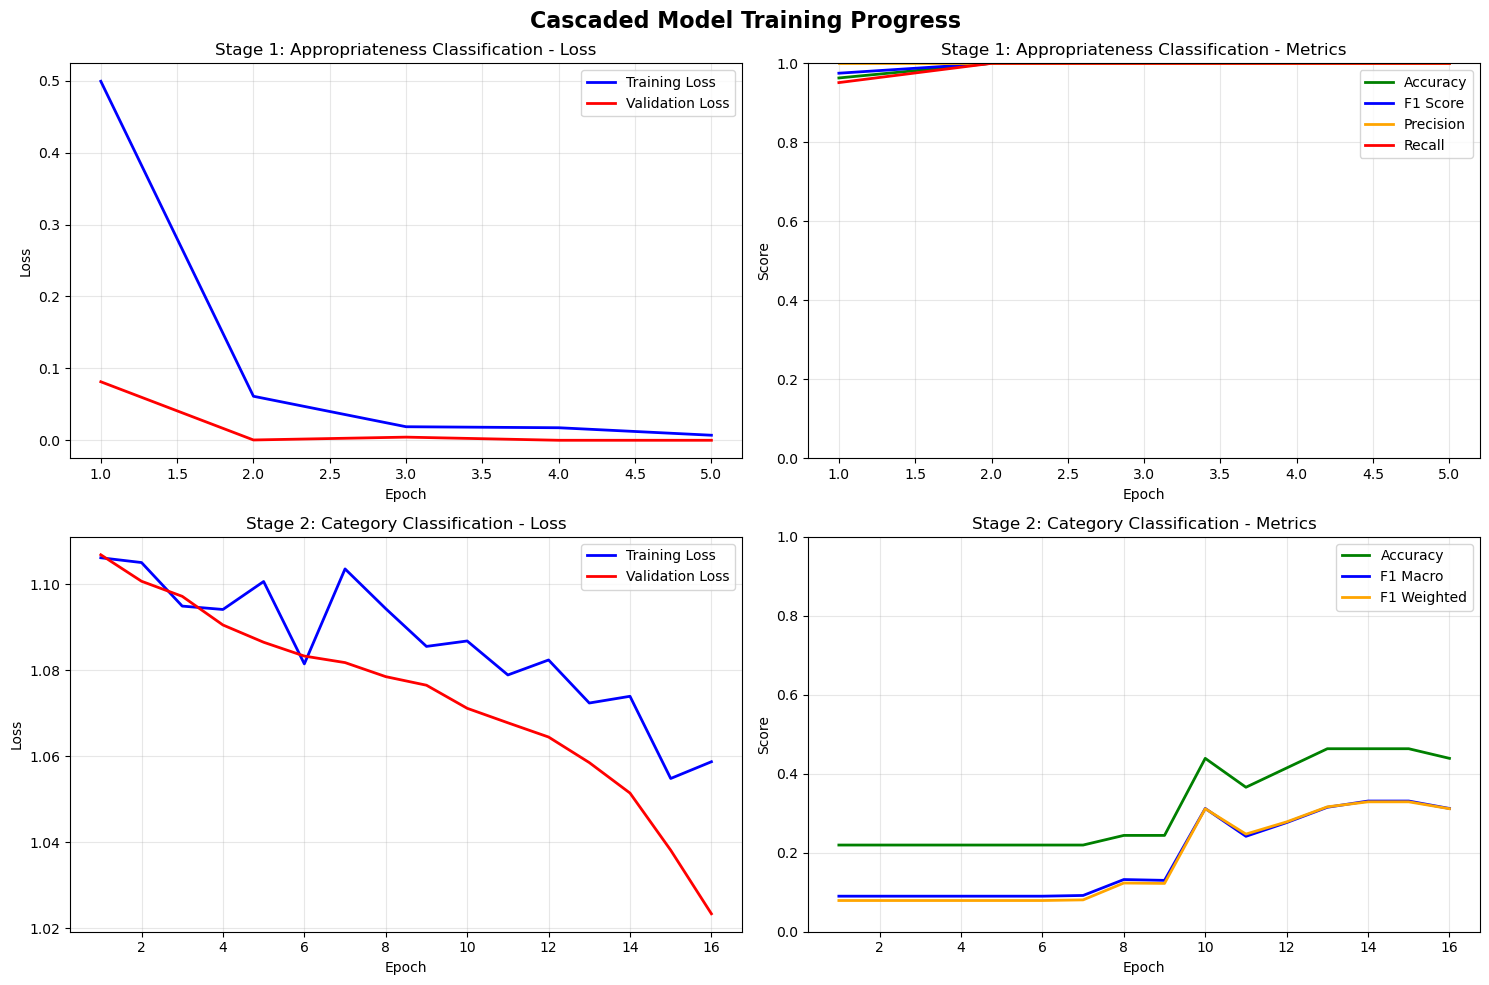

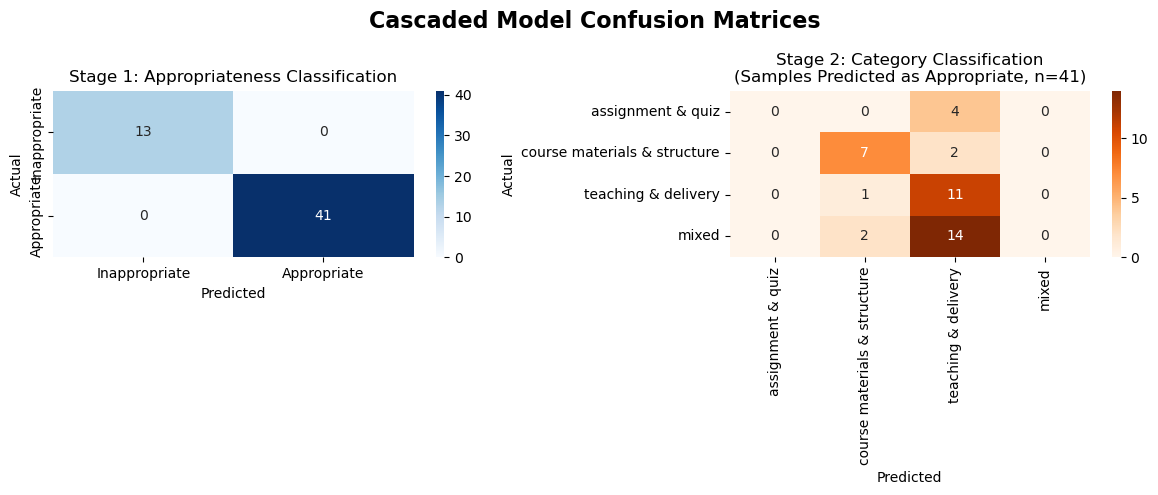

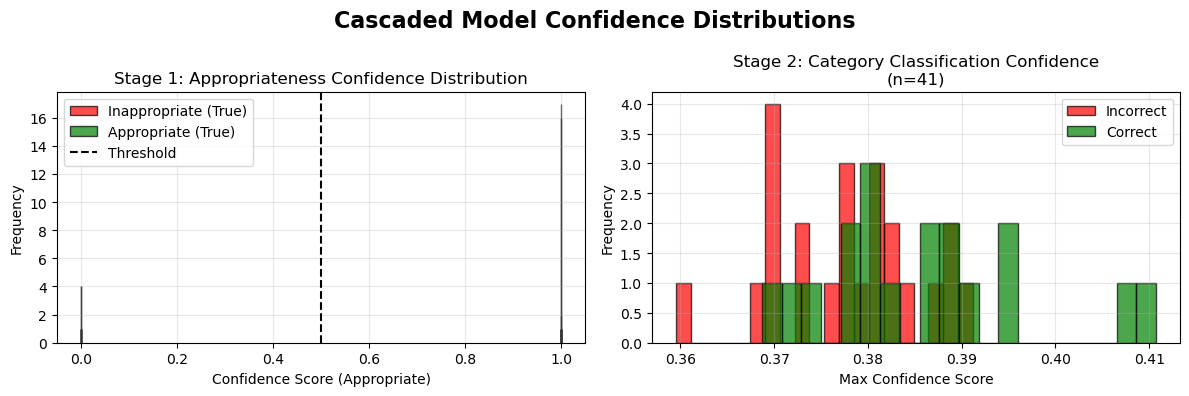


Appropriateness Classification Report:
               precision    recall  f1-score   support

Inappropriate     1.0000    1.0000    1.0000        13
  Appropriate     1.0000    1.0000    1.0000        41

     accuracy                         1.0000        54
    macro avg     1.0000    1.0000    1.0000        54
 weighted avg     1.0000    1.0000    1.0000        54


Categorisation Classification Report:
Evaluated on 41 samples predicted as appropriate
Of these, 41 were actually appropriate

                              precision    recall  f1-score   support

           assignment & quiz     0.0000    0.0000    0.0000         4
course materials & structure     0.7000    0.7778    0.7368         9
         teaching & delivery     0.3548    0.9167    0.5116        12
                       mixed     0.0000    0.0000    0.0000        16

                    accuracy                         0.4390        41
                   macro avg     0.2637    0.4236    0.3121        41
       

In [12]:
visualize_cascaded_training_results(
    appropriate_model=appropriate_model, 
    category_model=category_model, 
    dataset=val_dataset, 
    training_history_df=training_history_df, 
    device=device)

# Testing Model

Here, we test the model using the testing dataset to evaluate its performance on new, unseen data. We begin by loading the pretrained model that was automatically saved during training and then use it to generate labels for the testing set.

In [13]:
import torch
import torch.nn as nn
import os
from transformers import AutoTokenizer, AutoModelForSequenceClassification, AutoModel
from sklearn.metrics import f1_score, accuracy_score, precision_score, recall_score


def load_cascaded_models(results_dir="./results_cascaded_multi_class", 
                        model_name="roberta-base",
                        device=None):

    # Check if model files exist
    appropriate_path = os.path.join(results_dir, "best_appropriateness_model.pt")
    category_path = os.path.join(results_dir, "best_categorisation_model.pt")
    tokenizer_path = os.path.join(results_dir, "tokenizer")
    
    if not os.path.exists(appropriate_path):
        raise FileNotFoundError(f"Appropriateness model not found at: {appropriate_path}")
    if not os.path.exists(category_path):
        raise FileNotFoundError(f"Category model not found at: {category_path}")
    
    print(f"Loading models from: {results_dir}")
    print(f"Using device: {device}")

    # Load tokenizer
    if os.path.exists(tokenizer_path):
        print("Loading saved tokenizer")
        try:
            from transformers import AutoTokenizer
            tokenizer = AutoTokenizer.from_pretrained(tokenizer_path, use_fast=False)
        except Exception as e:
            print(f"Failed to load saved tokenizer ({e}). Loading from HuggingFace instead")
            tokenizer = AutoTokenizer.from_pretrained(model_name, use_fast=False)
    else:
        print(f"Loading tokenizer from {model_name}")
        tokenizer = AutoTokenizer.from_pretrained(model_name, use_fast=False)

    # Initialize models
    appropriate_model = AutoModelForSequenceClassification.from_pretrained(
        model_name, 
        num_labels=2,
        problem_type="single_label_classification"
    )
    
    category_model = CascadedCategoryModel(model_name)
    
    # Load trained weights
    appropriate_state_dict = torch.load(appropriate_path, map_location="cpu")
    category_state_dict = torch.load(category_path, map_location="cpu")

    appropriate_model.load_state_dict(appropriate_state_dict)
    category_model.load_state_dict(category_state_dict)
    
    # Move models to device  
    appropriate_model.to(device)
    category_model.to(device)

    # Set models to evaluation mode
    appropriate_model.eval()
    category_model.eval()
    
    print("Models loaded successfully.")
    
    return appropriate_model, category_model, tokenizer

def predict_with_cascaded_models(appropriate_model, category_model, tokenizer, 
                               texts, app_labels=None, cat_labels=None,
                               device=None, batch_size=8):
    
    appropriate_model.eval()
    category_model.eval()
    
    all_app_predictions = []
    all_cat_predictions = []
    all_app_probs = []
    all_cat_probs = []
    
    # Process in batches
    for i in range(0, len(texts), batch_size):
        batch_texts = texts[i:i+batch_size]
        
        # Tokenize batch
        inputs = tokenizer(
            batch_texts,
            padding=True,
            truncation=True,
            return_tensors='pt',
            max_length=256
        )
        
        input_ids = inputs['input_ids'].to(device)
        attention_mask = inputs['attention_mask'].to(device)
        
        with torch.no_grad():
            # Get appropriateness predictions
            app_outputs = appropriate_model(input_ids=input_ids, attention_mask=attention_mask)
            app_logits = app_outputs.logits
            app_probs = torch.softmax(app_logits, dim=1)
            app_preds = torch.argmax(app_logits, dim=1)
            
            # Get category predictions (for all samples, but only meaningful for appropriate ones)
            cat_outputs = category_model(input_ids=input_ids, attention_mask=attention_mask)
            cat_logits = cat_outputs.logits
            cat_probs = torch.softmax(cat_logits, dim=1)
            cat_preds = torch.argmax(cat_logits, dim=1)
            
            # Store predictions
            all_app_predictions.extend(app_preds.cpu().numpy())
            all_cat_predictions.extend(cat_preds.cpu().numpy())
            all_app_probs.extend(app_probs.cpu().numpy())
            all_cat_probs.extend(cat_probs.cpu().numpy())
    
    results = {
        'appropriateness_predictions': np.array(all_app_predictions),
        'category_predictions': np.array(all_cat_predictions),
        'appropriateness_probabilities': np.array(all_app_probs),
        'category_probabilities': np.array(all_cat_probs)
    }
    
    # Compute metrics if labels are provided
    if app_labels is not None:
        from sklearn.metrics import accuracy_score, f1_score, precision_score, recall_score
        
        app_acc = accuracy_score(app_labels, all_app_predictions)
        app_f1 = f1_score(app_labels, all_app_predictions, average='binary', zero_division=0)
        app_prec = precision_score(app_labels, all_app_predictions, average='binary', zero_division=0)
        app_rec = recall_score(app_labels, all_app_predictions, average='binary', zero_division=0)
        
        print(f"Appropriateness Classification Metrics:")
        print(f"Accuracy: {app_acc:.4f}")
        print(f"F1: {app_f1:.4f}")
        print(f"Precision: {app_prec:.4f}")
        print(f"Recall: {app_rec:.4f}")
        
        results['appropriateness_metrics'] = {
            'accuracy': app_acc,
            'f1': app_f1,
            'precision': app_prec,
            'recall': app_rec
        }

    if cat_labels is not None and app_labels is not None:
        # Filter to only samples predicted as appropriate
        app_pred_mask = (np.array(all_app_predictions) == 1)
        
        if app_pred_mask.sum() > 0:
            cat_true_filtered = np.array(cat_labels)[app_pred_mask]
            cat_pred_filtered = np.array(all_cat_predictions)[app_pred_mask]
            
            cat_acc = accuracy_score(cat_true_filtered, cat_pred_filtered)
            cat_f1_macro = f1_score(cat_true_filtered, cat_pred_filtered, average='macro', zero_division=0)
            cat_f1_weighted = f1_score(cat_true_filtered, cat_pred_filtered, average='weighted', zero_division=0)
            
            print(f"\nCategory Classification (Predicted Appropriate Samples, n={app_pred_mask.sum()}):")
            print(f"Accuracy: {cat_acc:.4f}")
            print(f"F1 Macro: {cat_f1_macro:.4f}")
            print(f"F1 Weighted: {cat_f1_weighted:.4f}")
            
            results['category_metrics'] = {
                'accuracy': cat_acc,
                'f1_macro': cat_f1_macro,
                'f1_weighted': cat_f1_weighted,
                'n_samples': app_pred_mask.sum()
            }
        else:
            print("Category Classification: No samples predicted as appropriate")
            results['category_metrics'] = None
    
    return results

In [14]:
# Load the pre-trained model
multi_label_model, binary_model, tokenizer = load_cascaded_models(
    results_dir="./results_cascaded_multi_class",
    model_name="roberta-base",
    device=device
)


Loading models from: ./results_cascaded_multi_class
Using device: mps
Loading saved tokenizer


Some weights of RobertaForSequenceClassification were not initialized from the model checkpoint at roberta-base and are newly initialized: ['classifier.dense.bias', 'classifier.dense.weight', 'classifier.out_proj.bias', 'classifier.out_proj.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.
Some weights of RobertaModel were not initialized from the model checkpoint at roberta-base and are newly initialized: ['pooler.dense.bias', 'pooler.dense.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


Models loaded successfully.


In [15]:
# Evaluate the prediction result using new, unseen data
results = predict_with_cascaded_models(
    appropriate_model, 
    category_model, 
    tokenizer, 
    texts= X_test.tolist(),
    app_labels=y_binary_test, 
    cat_labels=y_category_test,
    device=device)

Appropriateness Classification Metrics:
Accuracy: 0.9904
F1: 0.9932
Precision: 0.9865
Recall: 1.0000

Category Classification (Predicted Appropriate Samples, n=74):
Accuracy: 0.3784
F1 Macro: 0.2793
F1 Weighted: 0.2396
